In [1]:
import pandas as pd

# Load the dataset

df= pd.read_csv('netflix_titles.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [2]:
#count total number of duplicated rows in the dataset

print("Dataset shape before removing duplicates:", df.shape)
duplicates=df.duplicated().sum()
print("number of duplicated rows:", duplicates )

df=df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape before removing duplicates: (8807, 12)
number of duplicated rows: 0
Dataset shape after removing duplicates: (8807, 12)


In [3]:
#handle missing values and counting missing values in each column

missing_values=df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [4]:
df=df.dropna(subset=["date_added"])
df=df.fillna({"director":"unknown","cast":"unknown","country":"unknown"})
mode_rating=df["rating"].mode()[0]
print("Most common rating:", mode_rating)
df["rating"]=df["rating"].fillna(mode_rating)
duration_mode=df["duration"].mode()[0]
print("Most common duration:", duration_mode)
df["duration"]=df["duration"].fillna(duration_mode)

#now checking if there are any missing values left
missing_values_after=df.isnull().sum()
print("Missing values in each column after handling:\n", missing_values_after)

Most common rating: TV-MA
Most common duration: 1 Season
Missing values in each column after handling:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [5]:
#check for types of all columns
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [6]:
#check for quick overview
print(df.info())

#change format

# Convert date_added to datetime (clean leading/trailing spaces first)
df["date_added"] = pd.to_datetime(df["date_added"].astype(str).str.strip(), errors="coerce")

# Extract numeric duration for movies
df['duration_minutes'] = df['duration'].str.extract('(\d+)').astype(int)

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.4+ KB
None


In [7]:
#standardize text columns
#count unique values in 'country' column

print(df["country"].value_counts())

country
United States                                             2812
India                                                      972
unknown                                                    830
United Kingdom                                             418
Japan                                                      244
                                                          ... 
Germany, Canada, United States                               1
Denmark, United Kingdom, South Africa, Sweden, Belgium       1
Serbia, South Korea, Slovenia                                1
United Kingdom, Spain, Belgium                               1
South Africa, United States, Japan                           1
Name: count, Length: 749, dtype: int64


In [8]:
#consider the first country listed for entries with multiple countries

df["country"] = df["country"].str.split(",").str[0]
df["country"] = df["country"].str.strip()
print(df["country"].value_counts())
df["country"].unique()


#replace empty strings with "unknown" and verify the changes

df["country"]=df["country"].replace("", "unknown")
print(df["country"].value_counts())

#standardize country names by stripping whitespace and converting to title case
df["country"] = df["country"].str.strip()
df["country"] = df["country"].str.title()

country
United States     3205
India             1008
unknown            830
United Kingdom     627
Canada             271
                  ... 
West Germany         1
Slovenia             1
Guatemala            1
Jamaica              1
Somalia              1
Name: count, Length: 87, dtype: int64
country
United States     3205
India             1008
unknown            832
United Kingdom     627
Canada             271
                  ... 
West Germany         1
Slovenia             1
Guatemala            1
Jamaica              1
Somalia              1
Name: count, Length: 86, dtype: int64


count    8797.000000
mean       69.896669
std        50.804283
min         1.000000
25%         2.000000
50%        88.000000
75%       106.000000
max       312.000000
Name: duration_minutes, dtype: float64
count    8797.000000
mean     2014.183472
std         8.822191
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


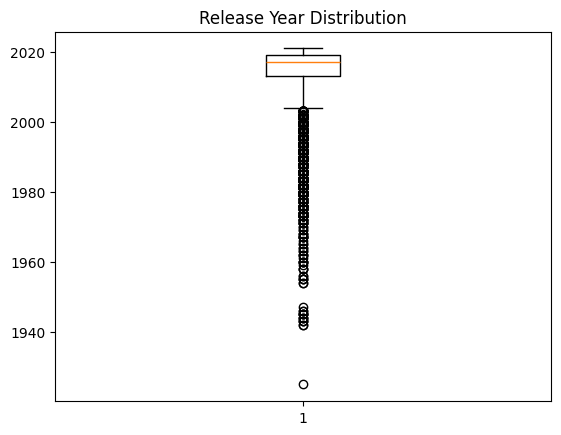

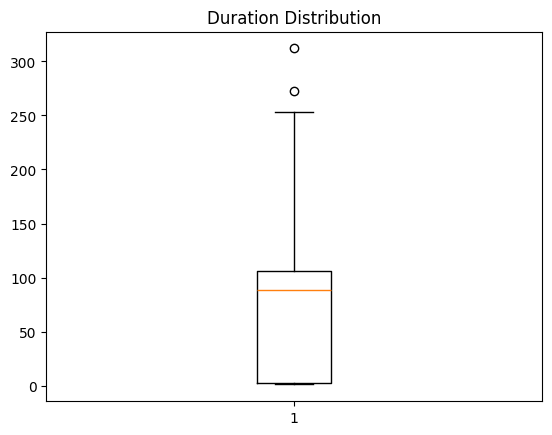

In [9]:
#check for outliers
print(df["duration_minutes"].describe())
print(df["release_year"].describe())

#plot for move verficiation
import matplotlib.pyplot as plt
plt.boxplot(df["release_year"])
plt.title("Release Year Distribution")
plt.show()

plt.boxplot(df["duration_minutes"])
plt.title("Duration Distribution")     
plt.show()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


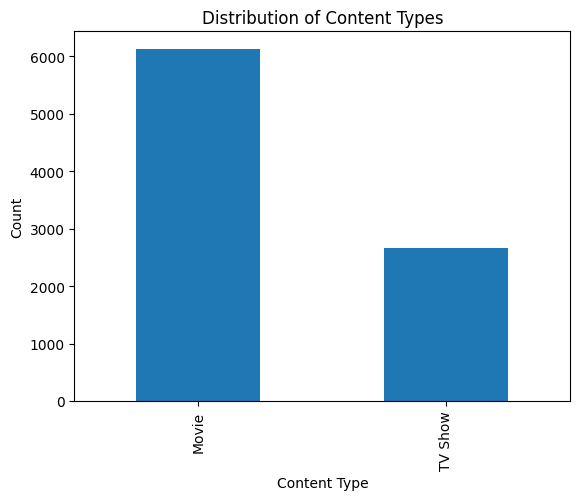

In [ ]:
#move to EDA
import matplotlib


type_counts=df["type"].value_counts()
print(type_counts)

#prove by visualization using matplotlib
import matplotlib.pyplot as plt
type_counts.plot(kind="bar")
plt.title("Distribution of Content Types")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

#conclusion: netflix has more movies than TV shows in the dataset


country
United States     3205
India             1008
Unknown            832
United Kingdom     627
Canada             271
Japan              258
France             212
South Korea        211
Spain              181
Mexico             134
Name: count, dtype: int64


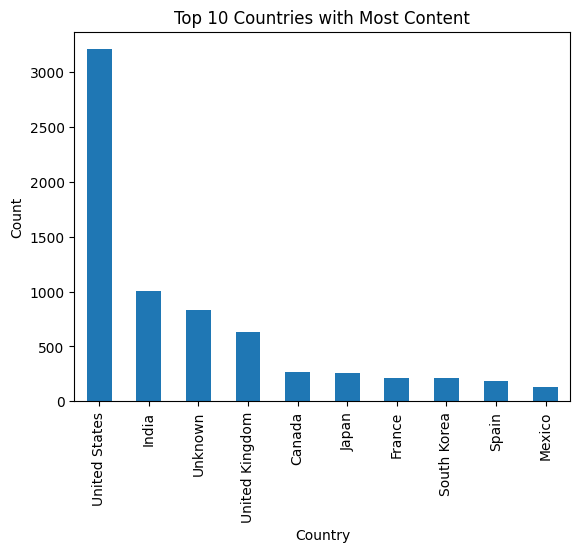

In [13]:
top_countries=df["country"].value_counts().head(10)
print(top_countries)

# Visualize the top 10 countries with the most content
top_countries.plot(kind="bar")
plt.title("Top 10 Countries with Most Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

listed_in
Dramas, International Movies    362
Documentaries                   359
Stand-Up Comedy                 334
Name: count, dtype: int64


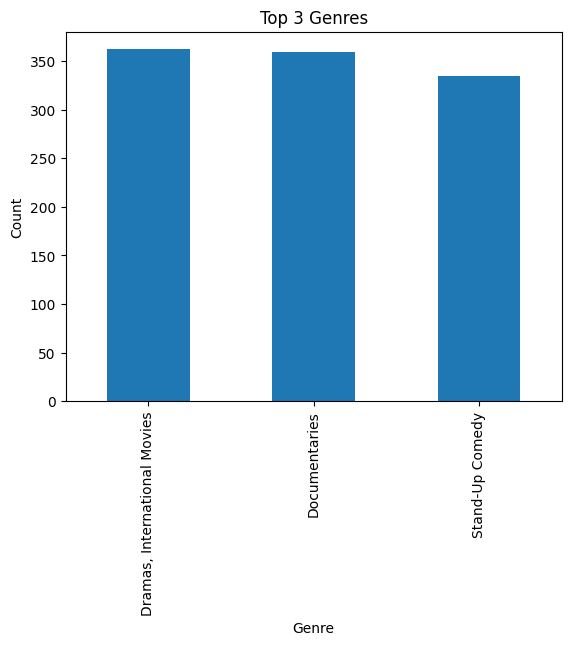

In [14]:
top_genres=df["listed_in"].value_counts().head(3)
print(top_genres)

# Visualize the top 3 genres
top_genres.plot(kind="bar")
plt.title("Top 3 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

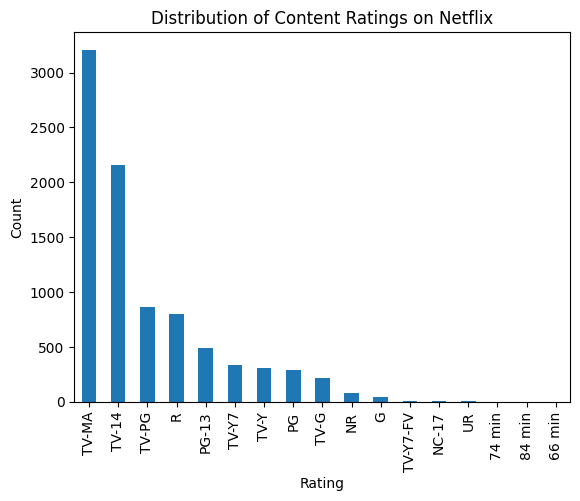

In [15]:
rating_counts = df["rating"].value_counts()

rating_counts.plot(kind="bar")

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
#final insights:
#1. Netflix has more movies than TV shows in the dataset.
#2. The United States is the country with the most content on Netflix, followed by India and the United Kingdom.
#3. The most common genres on Netflix are "Dramas", "Comedies", and "Documentaries".
#4. The majority of content on Netflix is rated "TV-MA", followed by "TV-14" and "R".